In [262]:
import pandas as pd
from collections import Counter
import numpy as np
from scipy.stats import entropy

In [263]:
def jsd_divergence_between_sets(set1, set2, base=2):

    jsd_results = {}

    dict1 = {list(d.keys())[0]: list(d.values())[0] for d in set1}
    dict2 = {list(d.keys())[0]: list(d.values())[0] for d in set2}

    for question in dict1.keys():
        if question not in dict2:
            continue 

        p_counts = dict1[question]
        q_counts = dict2[question]

        p = np.array([p_counts.get(k, 0) for k in p_counts], dtype=float)
        q = np.array([q_counts.get(k, 0) for k in p_counts], dtype=float)

        p /= p.sum()
        q /= q.sum()

        epsilon = 1e-10
        p = np.clip(p, epsilon, 1)
        q = np.clip(q, epsilon, 1)

        m = 0.5 * (p + q)
        jsd_pq = 0.5 * (entropy(p, m, base=base) + entropy(q, m, base=base)) 
        jsd_results[question] = jsd_pq

    return jsd_results

In [ ]:
group_var_dict = {"V201549x" : "Race", 'V202022' : "Discuss Politics", 'V201200' : "Ideology", 'V201231x' : "Party", 
                  'V201452' : "Church", 'V201600' : "Gender", 'V202406' : "Political Interest"}

groups = {
    'V201549x': {1: 'White', 2: 'Black', 3: 'Asian', 4: 'Native American', 5: 'Hispanic'},
    'V202022': {
            1: 'Like to discuss politics',
            2: 'Never discuss politics'
            },
    'V201200': {
            1: "Extremely liberal",
            2: "Liberal",
            3: "Slightly liberal",
            4: "Moderate",
            5: "Slightly conservative",
            6: "Conservative",
            7: "Extremely conservative"
        },
    'V201231x': {
            1: "Strong democrat",
            2: "Weak democrat",
            3: "Democrat-leaning indep.",
            4: "Independent",
            5: "Republican-leaning indep.",
            6: "Weak republican",
            7: "Strong republican"
        },
    'V201452': {1: "Attend church", 2: "Does not attend church"},
    'V201600': {1: "Man", 2: "Woman"},
    'V202406': {1: "Very", 2: "Somewhat", 3: "Not very", 4: "Not at all"}
}

label_to_group = {}

for var, mapping in groups.items():
    for code, label in mapping.items():
        label_to_group[label] = group_var_dict[var]

In [ ]:
qids = ["V201324","V201416", "V202234", "V202257", "V202287", "V202332", "V202337", "V202348", "V202371", "V202378"]
name_dict = {"V201324" : "Current Economy", "V201416" : "Gay Marriage", "V202234" : "Refugee Allowing", 
            "V202257" : "Income Inequality", "V202287" : "Gender Role", "V202332": "Climate Change",
            "V202337": "Gun Regulation", "V202348": "Drug Addiction", "V202371": "Race Diversity", "V202378": "Health Insurance"}
qids_reverse_coded = ["V201416", "V202234", "V202257", "V202287", "V202332", "V202371"]

groups_keys = groups.keys()

def get_counts_group(path, qids, key): #function to get a dict with counts for each question

    value_list = {}

    for number, group in groups[key].items():

        value_list[group] = []

        for id in qids:
            df = pd.read_csv(path + id + ".csv")
            df_group = df[df[key] == number]

            df_group.loc[:, 'Response'] = pd.to_numeric(df_group['Response'], errors='coerce')     
            value_counts = Counter(df_group['Response'].dropna())

            if id in ["V201324", "V202332"]:
                answers = {i: value_counts[i] for i in range(1, 6)}
            else:
                answers = {i: value_counts[i] for i in range(1, 4)}

            value_list[group].append({name_dict[id] : answers})

    return value_list

In [266]:
def get_human_counts_group(path, qids, key): #getting results from anes 2020
    value_list = {}

    for number, group in groups[key].items():
        value_list[group] = []
        df = pd.read_csv(path)
        df_group = df[df[key] == number]

        for id in qids:
            human_counts = Counter(df_group[id].dropna())

            if id in ["V201324", "V202332"]:
                answers = {i: human_counts[i] for i in range(1, 6)}
            else:
                answers = {i: human_counts[i] for i in range(1, 4)}

            value_list[group].append({name_dict[id] : answers})

    return value_list

#human_results = get_human_counts_group("data/2020 ANES_test.csv", qids)

In [ ]:
# GPT-4.1
model_name = 'gpt4.1'

human_results_groups = {}
replicate_results_groups = {}
reformulated_results_groups = {}
priming_results_groups = {}
preamble_results_groups = {}
reversed_results_groups = {}

for key in groups_keys:
    human_results_groups[group_var_dict[key]] = get_human_counts_group("data/2020 ANES_test.csv", qids, key)
    replicate_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/Gpt4.1-Mini-Determinstic/main_mq_results/full_results_2020_", qids, key)
    reformulated_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/Gpt4.1-Mini-Determinstic/main_mq_reform_results/full_results_2020_", qids, key)
    priming_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/Gpt4.1-Mini-Determinstic/main_mq_priming_results/full_results_2020_", qids, key)
    preamble_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/Gpt4.1-Mini-Determinstic/main_mq_preamble_results/full_results_2020_", qids, key)
    reversed_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/Gpt4.1-Mini-Determinstic/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded, key)


results = [human_results_groups, replicate_results_groups, reformulated_results_groups, priming_results_groups, preamble_results_groups, reversed_results_groups]    



/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/624287208.py:6: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/624287208.py:6: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/624287208.py:6: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/624287208.py:6: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [ ]:
# Llama8b
model_name = 'llama8b'
human_results_groups = {}
replicate_results_groups = {}
reformulated_results_groups = {}
priming_results_groups = {}
preamble_results_groups = {}
reversed_results_groups = {}

for key in groups_keys:
    human_results_groups[group_var_dict[key]] = get_human_counts_group("data/2020 ANES_test.csv", qids, key)
    replicate_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/8B-Llama/main_mq_results/full_results_2020_", qids, key)
    reformulated_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/8B-Llama/main_mq_reform_3rdP_results/full_results_2020_", qids, key)
    priming_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/8B-Llama/Priming/Original/full_results_2020_", qids, key)
    preamble_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/8B-Llama/Preamble/Original/full_results_2020_", qids, key)
    reversed_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/8B-Llama/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded, key)

results = [human_results_groups, replicate_results_groups, reformulated_results_groups, priming_results_groups, preamble_results_groups, reversed_results_groups]    

/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/624287208.py:6: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/624287208.py:6: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/624287208.py:6: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/624287208.py:6: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [ ]:
# llama70b
model_name = 'llama70b'
human_results_groups = {}
replicate_results_groups = {}
reformulated_results_groups = {}
priming_results_groups = {}
preamble_results_groups = {}
reversed_results_groups = {}
for key in groups_keys:
    human_results_groups[group_var_dict[key]] = get_human_counts_group("data/2020 ANES_test.csv", qids, key)
    replicate_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/70B-Llama/main_mq_results/full_results_2020_", qids, key)
    reformulated_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/70B-Llama/main_mq_reform_results/full_results_2020_", qids, key)
    priming_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/70B-Llama/main_mq_priming_results/full_results_2020_", qids, key)
    preamble_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/70B-Llama/main_mq_preamble_results/full_results_2020_", qids, key)
    reversed_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/70B-Llama/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded, key)

results = [human_results_groups, replicate_results_groups, reformulated_results_groups, priming_results_groups, preamble_results_groups, reversed_results_groups]    


/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/624287208.py:6: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/624287208.py:6: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/624287208.py:6: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/624287208.py:6: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [ ]:
replicate_jsd_groups = []

for key, value in results[0].items():
        for key_1 in results[0][key].keys():
            replicate_jsd_groups.append({key_1: jsd_divergence_between_sets(results[0][key][key_1], results[1][key][key_1])})
            
dict_jsd = {list(d.keys())[0]: list(d.values())[0] for d in replicate_jsd_groups}

replicate_jsd_groups_df = pd.DataFrame.from_dict(dict_jsd, orient="index")
replicate_jsd_groups_df.head(20)

replicate_jsd_groups_df['Average'] = replicate_jsd_groups_df.mean(axis=1)

replicate_jsd_groups_df.index = pd.MultiIndex.from_arrays(
    [replicate_jsd_groups_df.index.map(label_to_group), replicate_jsd_groups_df.index],
    names=["Group", "Category"]
)


In [269]:
replicate_jsd_groups_df.head(10)

Current Economy  Gay Marriage  \
Group            Category                                                  
Race             White                            0.316013      0.141394   
                 Black                            0.330130      0.198051   
                 Asian                            0.310284      0.124089   
                 Native American                  0.213464      0.108722   
                 Hispanic                         0.339197      0.153067   
Discuss Politics Like to discuss politics         0.298936      0.144606   
                 Never discuss politics           0.300587      0.166646   
Ideology         Extremely liberal                0.424191      0.042608   
                 Liberal                          0.275333      0.025925   
                 Slightly liberal                 0.212485      0.055067   

                                           Refugee Allowing  \
Group            Category                                     
Race             White                             0.270907   
                 Black                             0.318833   
                 Asian                             0.261927   
                 Native American                   0.263801   
                 Hispanic                          0.348336   
Discuss Politics Like to discuss politics          0.264653   
                 Never discuss politics            0.431975   
Ideology         Extremely liberal                 0.058766   
                 Liberal                           0.069950   
                 Slightly liberal                  0.134290   

                                           Income Inequality  Gender Role  \
Group            Category                                                   
Race             White                              0.213409     0.013397   
                 Black                              0.131719     0.040734   
                 Asian                              0.170328     0.023765   
                 Native American                    0.139994     0.004839   
                 Hispanic                           0.199283     0.035703   
Discuss Politics Like to discuss politics           0.193379     0.014751   
                 Never discuss politics             0.294758     0.019132   
Ideology         Extremely liberal                  0.076514     0.061790   
                 Liberal                            0.094025     0.061349   
                 Slightly liberal                   0.176424     0.088370   

                                           Climate Change  Gun Regulation  \
Group            Category                                                   
Race             White                           0.419995        0.112953   
                 Black                           0.362591        0.210190   
                 Asian                           0.400863        0.115500   
                 Native American                 0.342630        0.217327   
                 Hispanic                        0.419082        0.081152   
Discuss Politics Like to discuss politics        0.428435        0.121153   
                 Never discuss politics          0.284451        0.095549   
Ideology         Extremely liberal               0.742771        0.020644   
                 Liberal                         0.529957        0.118535   
                 Slightly liberal                0.505055        0.281688   

                                           Drug Addiction  Race Diversity  \
Group            Category                                                   
Race             White                           0.175705        0.176149   
                 Black                           0.159677        0.247332   
                 Asian                           0.153104        0.244144   
                 Native American                 0.161194        0.153668   
                 Hispanic                        0.181850    

In [ ]:
from copy import deepcopy 
reversed_results_groups_copy = deepcopy(reversed_results_groups)
for key, value in reversed_results_groups_copy.items():
        for key_1 in reversed_results_groups_copy[key].keys(): 
            reversed_results_groups[key][key_1][0]["Gay Marriage"][1] = reversed_results_groups_copy[key][key_1][0]["Gay Marriage"][3]
            reversed_results_groups[key][key_1][0]["Gay Marriage"][3] = reversed_results_groups_copy[key][key_1][0]["Gay Marriage"][1]

            reversed_results_groups[key][key_1][1]["Refugee Allowing"][1] = reversed_results_groups_copy[key][key_1][1]["Refugee Allowing"][2]
            reversed_results_groups[key][key_1][1]["Refugee Allowing"][2] = reversed_results_groups_copy[key][key_1][1]["Refugee Allowing"][1]

            reversed_results_groups[key][key_1][2]["Income Inequality"][1] = reversed_results_groups_copy[key][key_1][2]["Income Inequality"][2]
            reversed_results_groups[key][key_1][2]["Income Inequality"][2] = reversed_results_groups_copy[key][key_1][2]["Income Inequality"][1]

            reversed_results_groups[key][key_1][3]["Gender Role"][1] = reversed_results_groups_copy[key][key_1][3]["Gender Role"][2]
            reversed_results_groups[key][key_1][3]["Gender Role"][2] = reversed_results_groups_copy[key][key_1][3]["Gender Role"][1]

            reversed_results_groups[key][key_1][4]["Climate Change"][1] = reversed_results_groups_copy[key][key_1][4]["Climate Change"][5]
            reversed_results_groups[key][key_1][4]["Climate Change"][2] = reversed_results_groups_copy[key][key_1][4]["Climate Change"][4]
            reversed_results_groups[key][key_1][4]["Climate Change"][4] = reversed_results_groups_copy[key][key_1][4]["Climate Change"][2]
            reversed_results_groups[key][key_1][4]["Climate Change"][5] = reversed_results_groups_copy[key][key_1][4]["Climate Change"][1]

            reversed_results_groups[key][key_1][5]["Race Diversity"][1] = reversed_results_groups_copy[key][key_1][5]["Race Diversity"][2]
            reversed_results_groups[key][key_1][5]["Race Diversity"][2] = reversed_results_groups_copy[key][key_1][5]["Race Diversity"][1]


### Reversed-Coded - Replicate

In [273]:
reversed_jsd_groups = []

for key, value in results[0].items():
        for key_1 in results[5][key].keys():
            reversed_jsd_groups.append({key_1: jsd_divergence_between_sets(results[0][key][key_1], results[5][key][key_1])})
            
dict_jsd = {list(d.keys())[0]: list(d.values())[0] for d in reversed_jsd_groups}

reversed_jsd_groups_df = pd.DataFrame.from_dict(dict_jsd, orient="index")
reversed_jsd_groups_df.head(20)

reversed_jsd_groups_df['Average'] = reversed_jsd_groups_df.mean(axis=1)

reversed_jsd_groups_df.index = pd.MultiIndex.from_arrays(
    [reversed_jsd_groups_df.index.map(label_to_group), reversed_jsd_groups_df.index],
    names=["Group", "Category"]
)

In [ ]:
reversed_vs_replicate_jsd_df = reversed_jsd_groups_df - replicate_jsd_groups_df

df = reversed_vs_replicate_jsd_df.copy()

avg_col = df["Average"]

sorted_cols = (
    df.drop(columns=["Average"])
    .mean(axis=0)
    .sort_values()
    .index
)

reversed_vs_replicate_jsd_df_sorted = df[ list(sorted_cols) + ["Average"] ]

# file_path = f'tables/{model_name}-reversed_vs_replicate_jsd_df_sorted_full_t=0.csv'
# df_rounded = reversed_vs_replicate_jsd_df_sorted.round(3)
# df_rounded.to_csv(file_path, index=True)

#### Save representative slice

In [ ]:
numeric_cols = [
    'Race Diversity', 'Current Economy', 'Drug Addiction', 'Gun Regulation',
    'Gay Marriage', 'Climate Change', 'Gender Role', 'Income Inequality',
    'Health Insurance', 'Refugee Allowing', 'Average'
]

group_averages = reversed_vs_replicate_jsd_df_sorted.groupby('Group')[numeric_cols].mean().reset_index()
group_averages = group_averages.set_index('Group')
selected_columns = ['Race Diversity','Refugee Allowing','Income Inequality']

group_averages = group_averages[selected_columns]

file_path = f'tables/{model_name}-reversed_vs_replicate_jsd_df_rep_subset_t=0.csv'
df_rounded_reversed = group_averages.round(3)
df_rounded_reversed.to_csv(file_path, index=True)


### Reformulated - Replicate

In [ ]:
reformulated_jsd_groups = []

for key, value in results[0].items():
        for key_1 in results[0][key].keys():
            reformulated_jsd_groups.append({key_1: jsd_divergence_between_sets(results[0][key][key_1], results[2][key][key_1])})
            
dict_jsd = {list(d.keys())[0]: list(d.values())[0] for d in reformulated_jsd_groups}

reformulated_jsd_groups_df = pd.DataFrame.from_dict(dict_jsd, orient="index")
reformulated_jsd_groups_df.head(20)

reformulated_jsd_groups_df['Average'] = reformulated_jsd_groups_df.mean(axis=1)

reformulated_jsd_groups_df.index = pd.MultiIndex.from_arrays(
    [reformulated_jsd_groups_df.index.map(label_to_group), reformulated_jsd_groups_df.index],
    names=["Group", "Category"]
)

In [ ]:
reformulated_vs_replicate_jsd_df = reformulated_jsd_groups_df - replicate_jsd_groups_df

df = reformulated_vs_replicate_jsd_df.copy()

avg_col = df["Average"]

sorted_cols = (
    df.drop(columns=["Average"])
    .mean(axis=0)
    .sort_values()
    .index
)

reformulated_vs_replicate_jsd_df_sorted = df[ list(sorted_cols) + ["Average"] ]

# file_path = f'tables/{model_name}-reformulated_vs_replicate_jsd_df_sorted_full_t=0.csv'
# df_rounded = reformulated_vs_replicate_jsd_df_sorted.round(3)
# df_rounded.to_csv(file_path, index=True)

#### Save representative slice

In [ ]:
numeric_cols = [
    'Race Diversity', 'Current Economy', 'Drug Addiction', 'Gun Regulation',
    'Gay Marriage', 'Climate Change', 'Gender Role', 'Income Inequality',
    'Health Insurance', 'Refugee Allowing', 'Average'
]

group_averages = reformulated_vs_replicate_jsd_df_sorted.groupby('Group')[numeric_cols].mean().reset_index()
group_averages = group_averages.set_index('Group')
selected_columns = ['Race Diversity','Refugee Allowing','Income Inequality']

group_averages = group_averages[selected_columns]

# file_path = f'tables/{model_name}-reformulated_vs_replicate_jsd_df_rep_subset_t=0.csv'
# df_rounded_reformulated = group_averages.round(3)
# df_rounded_reformulated.to_csv(file_path, index=True)


### Priming - Replicate

In [ ]:
priming_jsd_groups = []

for key, value in results[0].items():
        for key_1 in results[0][key].keys():
            priming_jsd_groups.append({key_1: jsd_divergence_between_sets(results[0][key][key_1], results[3][key][key_1])})
            
dict_jsd = {list(d.keys())[0]: list(d.values())[0] for d in priming_jsd_groups}

priming_jsd_groups_df = pd.DataFrame.from_dict(dict_jsd, orient="index")
priming_jsd_groups_df.head(20)

priming_jsd_groups_df['Average'] = priming_jsd_groups_df.mean(axis=1)

priming_jsd_groups_df.index = pd.MultiIndex.from_arrays(
    [priming_jsd_groups_df.index.map(label_to_group), priming_jsd_groups_df.index],
    names=["Group", "Category"]
)

In [ ]:
priming_vs_replicate_jsd_df = priming_jsd_groups_df - replicate_jsd_groups_df

df = priming_vs_replicate_jsd_df.copy()

avg_col = df["Average"]

sorted_cols = (
    df.drop(columns=["Average"])
    .mean(axis=0)
    .sort_values()
    .index
)

priming_vs_replicate_jsd_df_sorted = df[ list(sorted_cols) + ["Average"] ]

# file_path = f'tables/{model_name}-priming_vs_replicate_jsd_df_sorted_full_t=0.csv'
# df_rounded = priming_vs_replicate_jsd_df_sorted.round(3)
# df_rounded.to_csv(file_path, index=True)

In [ ]:
numeric_cols = [
    'Race Diversity', 'Current Economy', 'Drug Addiction', 'Gun Regulation',
    'Gay Marriage', 'Climate Change', 'Gender Role', 'Income Inequality',
    'Health Insurance', 'Refugee Allowing', 'Average'
]

group_averages = priming_vs_replicate_jsd_df_sorted.groupby('Group')[numeric_cols].mean().reset_index()
group_averages = group_averages.set_index('Group')
selected_columns = ['Race Diversity','Refugee Allowing','Income Inequality']
group_averages = group_averages[selected_columns]


# file_path = f'tables/{model_name}-priming_vs_replicate_jsd_df_rep_subset_t=0.csv'
# df_rounded_priming = group_averages.round(3)
# df_rounded_priming.to_csv(file_path, index=True)


### Preamble - Replicate

In [ ]:
preamble_jsd_groups = []

for key, value in results[0].items():
        for key_1 in results[0][key].keys():
            preamble_jsd_groups.append({key_1: jsd_divergence_between_sets(results[0][key][key_1], results[4][key][key_1])})
            
dict_jsd = {list(d.keys())[0]: list(d.values())[0] for d in preamble_jsd_groups}

preamble_jsd_groups_df = pd.DataFrame.from_dict(dict_jsd, orient="index")
preamble_jsd_groups_df.head(20)

preamble_jsd_groups_df['Average'] = preamble_jsd_groups_df.mean(axis=1)

preamble_jsd_groups_df.index = pd.MultiIndex.from_arrays(
    [preamble_jsd_groups_df.index.map(label_to_group), preamble_jsd_groups_df.index],
    names=["Group", "Category"]
)

In [ ]:
preamble_vs_replicate_jsd_df = preamble_jsd_groups_df - replicate_jsd_groups_df

df = preamble_vs_replicate_jsd_df.copy()

avg_col = df["Average"]

sorted_cols = (
    df.drop(columns=["Average"])
    .mean(axis=0)
    .sort_values()
    .index
)

preamble_vs_replicate_jsd_df_sorted = df[ list(sorted_cols) + ["Average"] ]

# file_path = f'tables/{model_name}-preamble_vs_replicate_jsd_df_sorted_full_t=0.csv'
# df_rounded = preamble_vs_replicate_jsd_df_sorted.round(3)
# df_rounded.to_csv(file_path, index=True)


In [ ]:
numeric_cols = [
    'Race Diversity', 'Current Economy', 'Drug Addiction', 'Gun Regulation',
    'Gay Marriage', 'Climate Change', 'Gender Role', 'Income Inequality',
    'Health Insurance', 'Refugee Allowing', 'Average'
]

group_averages = preamble_vs_replicate_jsd_df_sorted.groupby('Group')[numeric_cols].mean().reset_index()
group_averages = group_averages.set_index('Group')
selected_columns = ['Race Diversity','Refugee Allowing','Income Inequality']
group_averages = group_averages[selected_columns]


# file_path = f'tables/{model_name}-preamble_vs_replicate_jsd_df_rep_subset_t=0.csv'
# df_rounded_preamble = group_averages.round(3)
# df_rounded_preamble.to_csv(file_path, index=True)


## Visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_stratified_jsd(jsd_groups_df, title='', output_path=''):
    df = jsd_groups_df.copy()

    avg_col = df["Average"]

    sorted_cols = (
        df.drop(columns=["Average"])
        .mean(axis=0)
        .sort_values()
        .index
    )

    df_sorted = df[ list(sorted_cols) + ["Average"] ]
   
    data = df_sorted.values
    row_labels = df_sorted.index
    col_labels = df_sorted.columns

    fig, ax = plt.subplots(figsize=(8, 5))  # adjust width/height for paper column
    im = ax.imshow(data, aspect='auto', cmap=plt.cm.RdYlGn_r, vmin=data.min(), vmax=data.max())

    ax.set_title(title)
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, rotation=35, ha='right', fontsize=10)
    ax.set_yticklabels(row_labels, fontsize=10)
    

    for edge, spine in ax.spines.items():
        spine.set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-0.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-0.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            text = f"{data[i, j]:.3f}"
            ax.text(j, i, text, ha="center", va="center", color="black", fontsize=8)

    # cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    # cbar.ax.tick_params(labelsize=9)
    plt.subplots_adjust(left=0.18, right=0.98, top=0.95, bottom=0.20)
        
    plt.show()


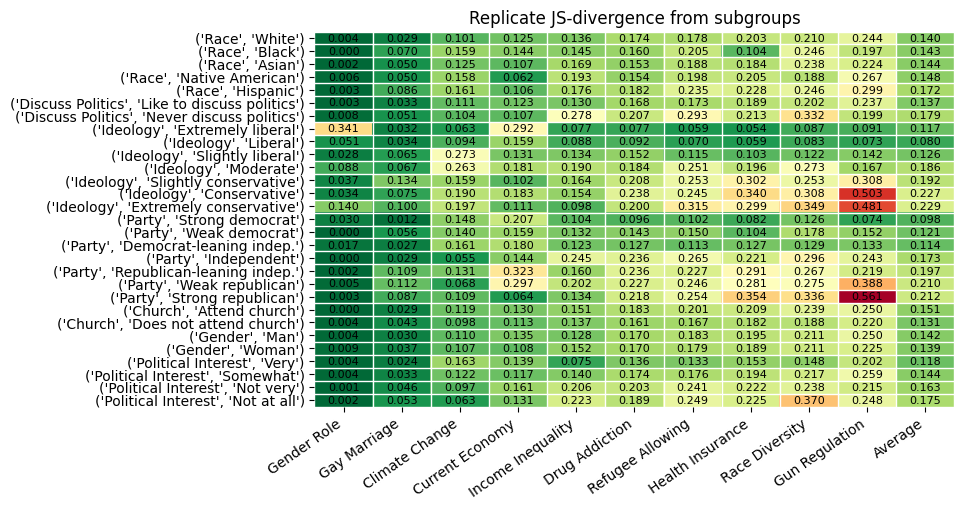

In [123]:
plot_stratified_jsd(replicate_jsd_groups_df, 'Replicate JS-divergence from subgroups','')



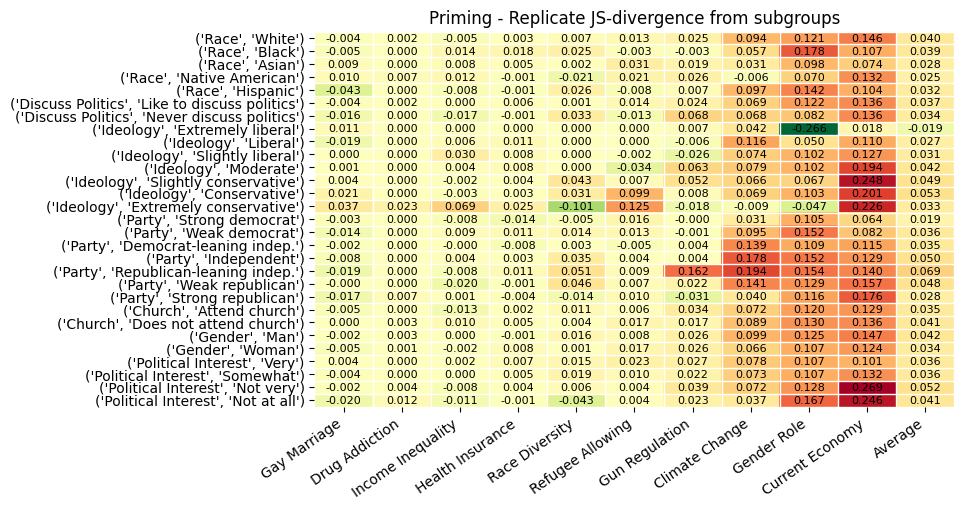

In [126]:
plot_stratified_jsd(priming_vs_replicate_jsd_df_sorted, 'Priming - Replicate JS-divergence from subgroups','')

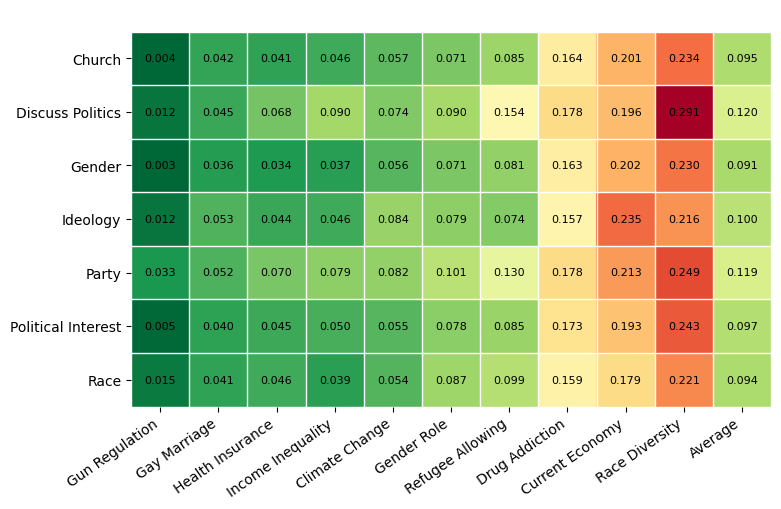

In [30]:
plot_stratified_jsd(group_averages, ' ','')